# Figuras 13/14 — Impacto do TLS (HTTP vs HTTPS, WebSocket vs WSS)

Reproduz o gráfico equivalente às **Figuras 13 e 14** do artigo *Comparison of WebSocket and HTTP Protocol Performance* (Łasocha & Badurowicz, 2021): tempo médio de transferência comparando cada protocolo com sua versão criptografada (TLS) — HTTP vs HTTPS e WebSocket vs WebSocket Secure (WSS) — por quantidade de cópias.

**Diferença em relação ao artigo original**: no artigo, a Figura 13 usa o laptop mais lento (Asus K50IN) e a Figura 14 o mais rápido (Acer Aspire 5), cada uma com 4 séries (HTTP, WebSocket, HTTPS, WSS). Aqui, como só existe um perfil de hardware, este notebook produz a comparação única equivalente, mas com **8 séries** (envio e recebimento para os 4 protocolos), já que as Figuras 6–11 desta replicação também separam envio de recebimento em vez de combiná-los como no artigo original.

## Configuração e carga dos dados

Este notebook espera estar em `data/notebook/` dentro do projeto, e busca os CSVs em `results/csv/` (dois níveis acima, depois entrando em `csv/`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# notebook está em data/notebook/ -> sobe 2 níveis (results/csv -> results -> raiz)
# e entra em results/csv
CSV_DIR = Path.cwd().parents[1] / "results" / "csv"

EXPECTED_COPIES = [1, 3, 10, 30, 100, 300, 1000, 3000]
EXPECTED_RUNS = 10

# (direção, protocolo) -> arquivo
FILES = {
    ("send", "HTTP"): "http-send-oh0.csv",
    ("send", "HTTPS"): "https-send-oh0.csv",
    ("send", "WS"): "ws-send-oh0.csv",
    ("send", "WSS"): "wss-send-oh0.csv",
    ("receive", "HTTP"): "http-receive-oh0.csv",
    ("receive", "HTTPS"): "https-receive-oh0.csv",
    ("receive", "WS"): "ws-receive-oh0.csv",
    ("receive", "WSS"): "wss-receive-oh0.csv",
}

print(f"Diretório de CSVs: {CSV_DIR.resolve()}")
print(f"Existe? {CSV_DIR.exists()}\n")
for (direction, proto), fname in FILES.items():
    path = CSV_DIR / fname
    print(f" - {proto:6s} ({direction:7s}) -> {fname}: {'encontrado' if path.exists() else 'NÃO encontrado'}")

Diretório de CSVs: /home/ryan-correia/Área de trabalho/.projetos/repositorios/github/ComputerNetworksManagement/ifpb/converged_networks/advanced_project/results/csv
Existe? True

 - HTTP   (send   ) -> http-send-oh0.csv: encontrado
 - HTTPS  (send   ) -> https-send-oh0.csv: encontrado
 - WS     (send   ) -> ws-send-oh0.csv: encontrado
 - WSS    (send   ) -> wss-send-oh0.csv: encontrado
 - HTTP   (receive) -> http-receive-oh0.csv: encontrado
 - HTTPS  (receive) -> https-receive-oh0.csv: encontrado
 - WS     (receive) -> ws-receive-oh0.csv: encontrado
 - WSS    (receive) -> wss-receive-oh0.csv: encontrado


In [2]:
dfs = {key: pd.read_csv(CSV_DIR / fname) for key, fname in FILES.items()}

for (direction, proto), df in dfs.items():
    print(f"--- {proto} ({direction}) ---")
    display(df.head(3))

--- HTTP (send) ---


,copies,run,time_ms
0,1,1,3.153
1,1,2,1.364
2,1,3,1.225


--- HTTPS (send) ---


,copies,run,time_ms
0,1,1,4.711
1,1,2,4.238
2,1,3,3.608


--- WS (send) ---


...

,copies,run,time_ms
0,1,1,3.876
1,1,2,3.846
2,1,3,2.789


--- WS (receive) ---


,copies,run,time_ms
0,1,1,0.772
1,1,2,0.440
2,1,3,0.278


--- WSS (receive) ---


,copies,run,time_ms
0,1,1,0.838
1,1,2,0.318
2,1,3,0.288


## Checagem de integridade dos dados

O artigo mede as cópias **1, 3, 10, 30, 100, 300, 1000, 3000**, com **10 repetições** (`run`) cada, para os 8 arquivos. A célula abaixo avisa se algum estiver com pontos faltando ou repetições insuficientes.

In [3]:
def check_integrity(df, label):
    counts = df.groupby("copies")["run"].count()
    missing = [c for c in EXPECTED_COPIES if c not in counts.index]
    extra = [c for c in counts.index if c not in EXPECTED_COPIES]
    under_run = counts[counts < EXPECTED_RUNS]
    ok = not missing and not extra and under_run.empty
    print(f"--- {label} ---")
    if missing:
        print(f"Faltando quantidades de cópias: {missing}")
    if extra:
        print(f"Quantidades de cópias inesperadas: {extra}")
    if not under_run.empty:
        print(f"Menos de {EXPECTED_RUNS} repetições para:\n{under_run}")
    if ok:
        print("OK")
    return ok

all_ok = True
for (direction, proto), df in dfs.items():
    all_ok = check_integrity(df, f"{proto} ({direction}) — {FILES[(direction, proto)]}") and all_ok

if not all_ok:
    print("\nATENÇÃO: pelo menos um arquivo está incompleto. Os gráficos abaixo podem ficar distorcidos até isso ser corrigido.")

--- HTTP (send) — http-send-oh0.csv ---
OK
--- HTTPS (send) — https-send-oh0.csv ---
OK
--- WS (send) — ws-send-oh0.csv ---
OK
--- WSS (send) — wss-send-oh0.csv ---
OK
--- HTTP (receive) — http-receive-oh0.csv ---
OK
--- HTTPS (receive) — https-receive-oh0.csv ---
OK
--- WS (receive) — ws-receive-oh0.csv ---
OK
--- WSS (receive) — wss-receive-oh0.csv ---
OK


## Cálculo das médias por quantidade de cópias

In [4]:
def summarize(df):
    g = df.groupby("copies")["time_ms"].mean()
    return g.reindex([c for c in EXPECTED_COPIES if c in g.index])

means = pd.DataFrame({key: summarize(df) for key, df in dfs.items()})
means.columns = [f"{proto} ({'envio' if d == 'send' else 'recebimento'})" for d, proto in means.columns]
means.round(2)

,HTTP (envio),HTTPS (envio),WS (envio),WSS (envio),HTTP (recebimento),HTTPS (recebimento),WS (recebimento),WSS (recebimento)
copies,,,,,,,,
1,1.73,3.91,0.67,0.60,1.33,2.84,0.32,0.36
3,4.54,11.86,1.25,0.46,3.07,7.26,0.51,0.60
10,10.84,35.31,4.21,1.78,9.74,30.19,1.34,1.33
30,31.85,106.68,9.64,6.23,22.47,89.91,4.90,2.63
100,91.38,327.10,27.44,17.95,71.84,284.96,16.04,15.44
300,161.71,815.04,39.71,36.74,153.28,720.74,30.99,32.91
1000,559.31,2953.84,91.41,88.15,430.02,2214.97,70.33,64.33
3000,1494.35,8090.32,205.89,234.50,1279.21,6766.97,254.72,209.99


## Figuras 13/14 — HTTP vs HTTPS e WS vs WSS (lado a lado)

Em vez de um único gráfico com 8 barras por quantidade de cópias (visualmente carregado), dividimos em dois painéis — um para o par HTTP/HTTPS, outro para o par WS/WSS — o que deixa o efeito do TLS mais fácil de enxergar em cada protocolo. Escala logarítmica no eixo Y, pelo mesmo motivo do notebook da Figura 10: os valores variam de frações de ms a milhares de ms.

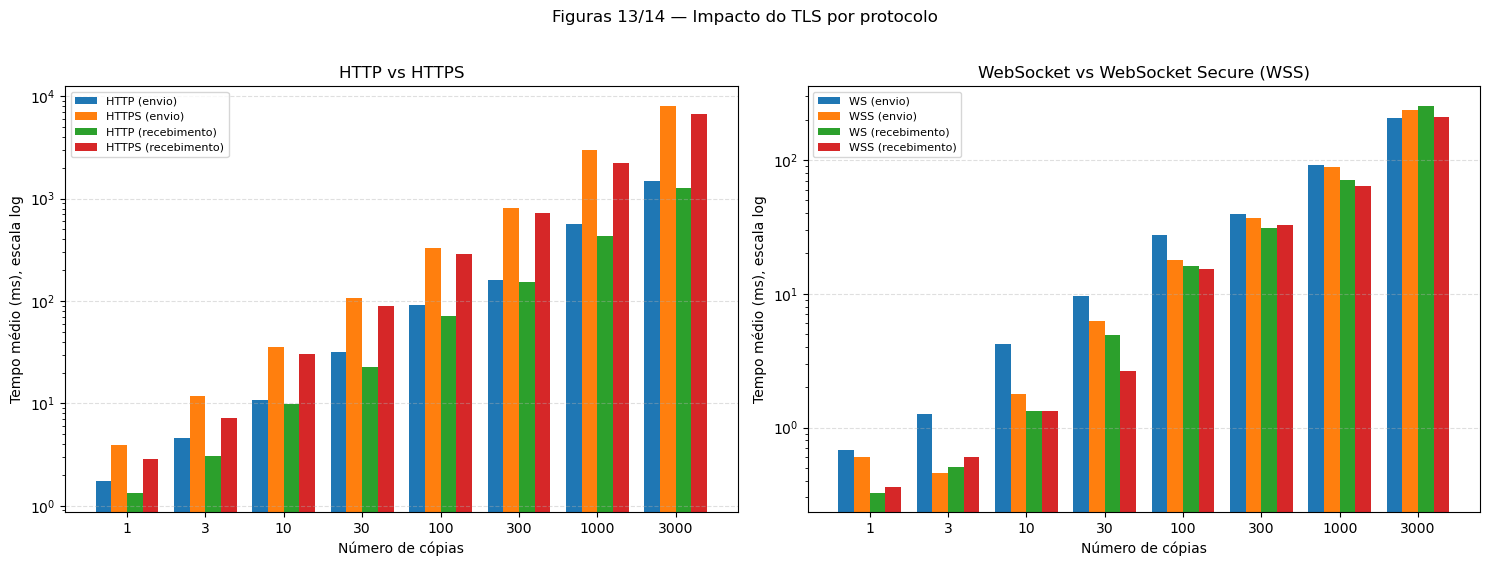

In [5]:
COLORS = {
    "HTTP (envio)": "#1f77b4", "HTTPS (envio)": "#ff7f0e",
    "HTTP (recebimento)": "#2ca02c", "HTTPS (recebimento)": "#d62728",
    "WS (envio)": "#1f77b4", "WSS (envio)": "#ff7f0e",
    "WS (recebimento)": "#2ca02c", "WSS (recebimento)": "#d62728",
}

def plot_pair(means_df, plain_label, secure_label, title, ax, log_scale=True):
    cols = [c for c in means_df.columns if c.startswith(plain_label + " ") or c.startswith(secure_label + " ")]
    sub = means_df[cols]
    labels = [str(c) for c in sub.index]
    x = np.arange(len(labels))
    n = len(cols)
    width = 0.8 / n
    for i, col in enumerate(cols):
        offset = (i - (n - 1) / 2) * width
        ax.bar(x + offset, sub[col], width, label=col, color=COLORS.get(col))
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_title(title)
    ax.set_xlabel("Número de cópias")
    ax.set_ylabel("Tempo médio (ms)" + (", escala log" if log_scale else ""))
    if log_scale:
        ax.set_yscale("log")
    ax.legend(fontsize=8)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
plot_pair(means, "HTTP", "HTTPS", "HTTP vs HTTPS", axes[0])
plot_pair(means, "WS", "WSS", "WebSocket vs WebSocket Secure (WSS)", axes[1])
fig.suptitle("Figuras 13/14 — Impacto do TLS por protocolo", y=1.02)
fig.tight_layout()
plt.show()

## Visão combinada (8 séries) — equivalente mais direto às Figuras 13/14 originais

Um único gráfico com as 8 séries, mais próximo do formato exato do artigo (que combina os 4 protocolos num só gráfico por hardware).

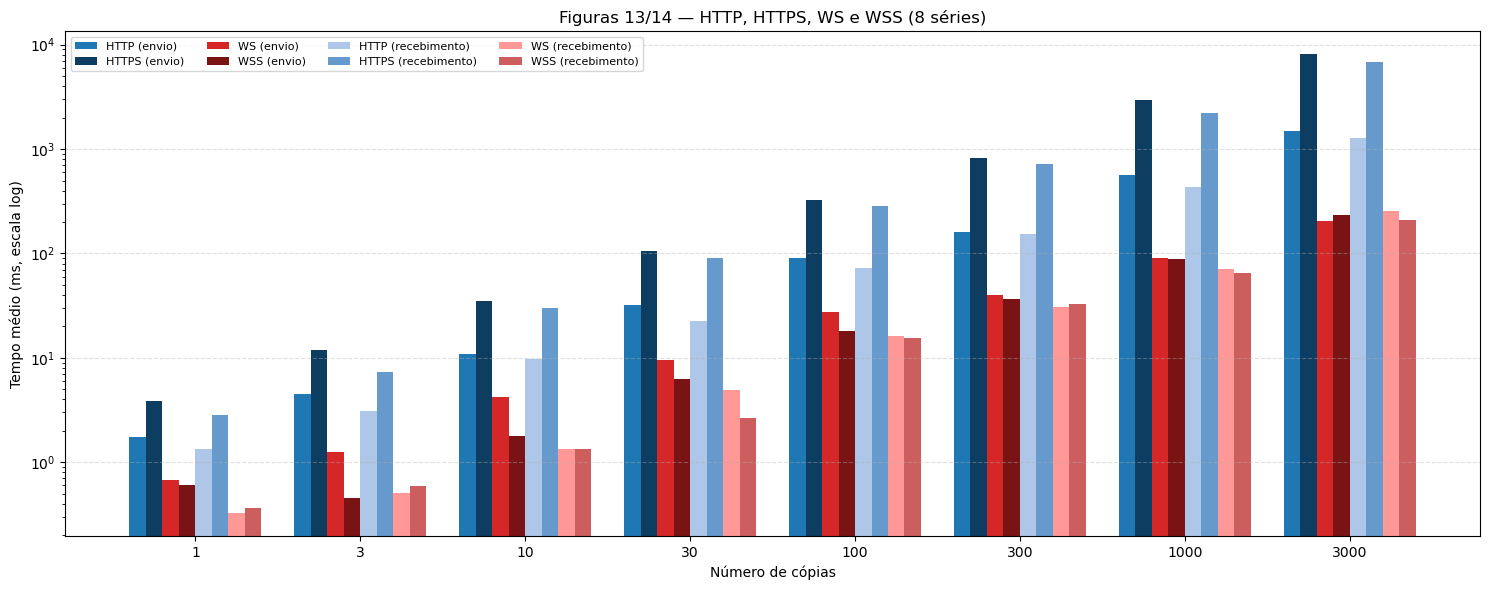

In [6]:
COLORS_FULL = {
    "HTTP (envio)": "#1f77b4", "HTTPS (envio)": "#0d3d61",
    "HTTP (recebimento)": "#aec7e8", "HTTPS (recebimento)": "#6699cc",
    "WS (envio)": "#d62728", "WSS (envio)": "#7a1414",
    "WS (recebimento)": "#ff9896", "WSS (recebimento)": "#cc5f5e",
}

def plot_combined(means_df, title):
    labels = [str(c) for c in means_df.index]
    x = np.arange(len(labels))
    n = len(means_df.columns)
    width = 0.8 / n
    fig, ax = plt.subplots(figsize=(15, 6))
    for i, col in enumerate(means_df.columns):
        offset = (i - (n - 1) / 2) * width
        ax.bar(x + offset, means_df[col], width, label=col, color=COLORS_FULL.get(col))
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_title(title)
    ax.set_xlabel("Número de cópias")
    ax.set_ylabel("Tempo médio (ms, escala log)")
    ax.set_yscale("log")
    ax.legend(ncol=4, fontsize=8)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    fig.tight_layout()
    return fig, ax

plot_combined(means, "Figuras 13/14 — HTTP, HTTPS, WS e WSS (8 séries)")
plt.show()

## Impacto percentual do TLS

Replica a conclusão central da seção 4.6 do artigo: o quanto o TLS realmente pesa em cada protocolo, por quantidade de cópias. O artigo original conclui que esse impacto é mínimo em ambos os protocolos — aqui dá para conferir se a mesma tendência se confirma nesta replicação.

In [7]:
def pct_impact(plain_col, secure_col):
    return ((means[secure_col] - means[plain_col]) / means[plain_col] * 100).round(1)

impact = pd.DataFrame({
    "HTTP->HTTPS envio (%)": pct_impact("HTTP (envio)", "HTTPS (envio)"),
    "HTTP->HTTPS recebimento (%)": pct_impact("HTTP (recebimento)", "HTTPS (recebimento)"),
    "WS->WSS envio (%)": pct_impact("WS (envio)", "WSS (envio)"),
    "WS->WSS recebimento (%)": pct_impact("WS (recebimento)", "WSS (recebimento)"),
})
impact

,HTTP->HTTPS envio (%),HTTP->HTTPS recebimento (%),WS->WSS envio (%),WS->WSS recebimento (%)
copies,,,,
1,126.0,113.1,-10.6,11.3
3,161.5,136.6,-63.3,18.6
10,225.6,209.8,-57.6,-0.6
30,234.9,300.1,-35.4,-46.2
100,258.0,296.6,-34.6,-3.7
300,404.0,370.2,-7.5,6.2
1000,428.1,415.1,-3.6,-8.5
3000,441.4,429.0,13.9,-17.6


## Exportando as figuras

Salva os gráficos (par lado a lado + combinado de 8 séries) como PNG em `results/notebook/figuras/`, prontos para o relatório.

Figuras salvas em: /home/ryan-correia/Área de trabalho/.projetos/repositorios/github/ComputerNetworksManagement/ifpb/converged_networks/advanced_project/data/plots


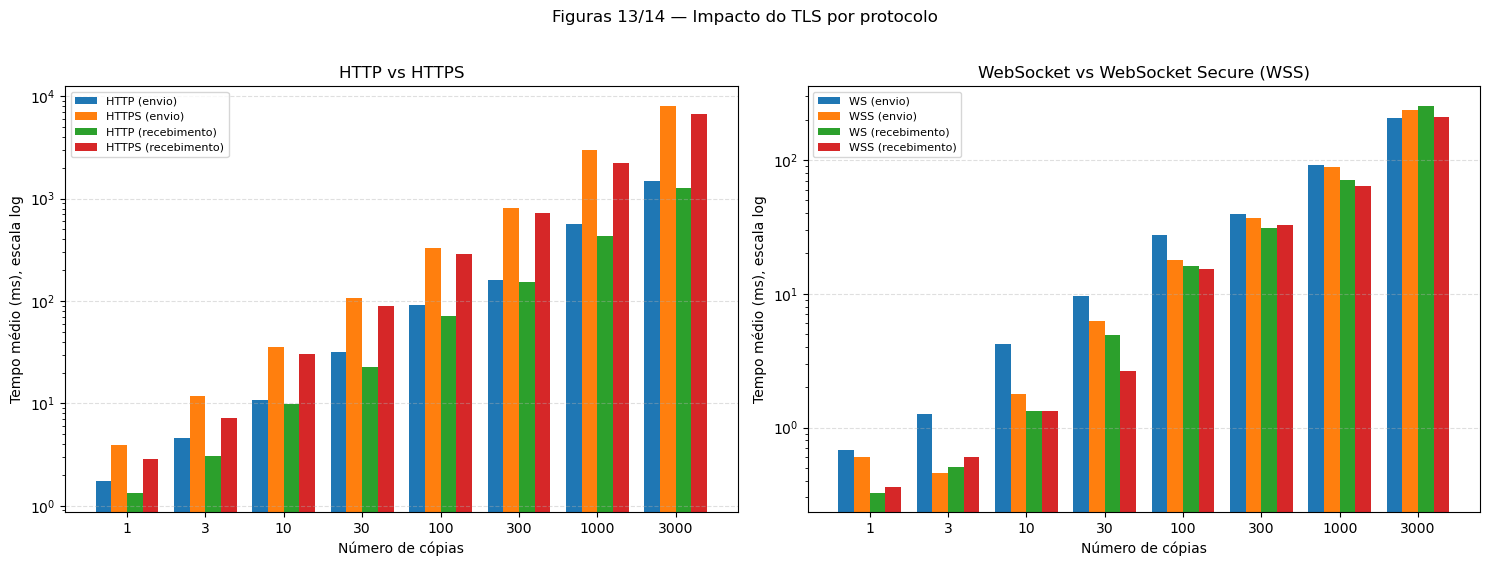

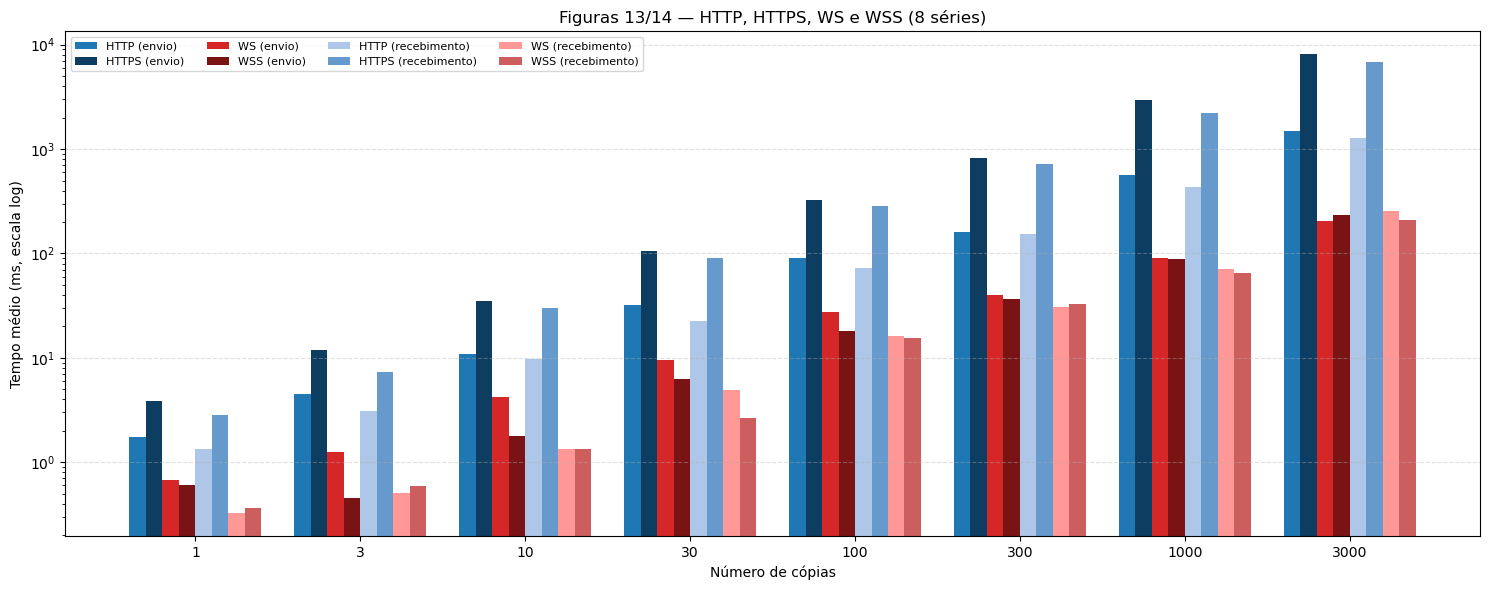

In [8]:
OUT_DIR = Path.cwd().parents[0] / "plots"
OUT_DIR.mkdir(exist_ok=True)

fig_pair, axes = plt.subplots(1, 2, figsize=(15, 5.5))
plot_pair(means, "HTTP", "HTTPS", "HTTP vs HTTPS", axes[0])
plot_pair(means, "WS", "WSS", "WebSocket vs WebSocket Secure (WSS)", axes[1])
fig_pair.suptitle("Figuras 13/14 — Impacto do TLS por protocolo", y=1.02)
fig_pair.tight_layout()
fig_pair.savefig(OUT_DIR / "figura13_14_tls_pares.png", dpi=150, bbox_inches="tight")

fig_combined, _ = plot_combined(means, "Figuras 13/14 — HTTP, HTTPS, WS e WSS (8 séries)")
fig_combined.savefig(OUT_DIR / "figura13_14_tls_combinado.png", dpi=150)

print(f"Figuras salvas em: {OUT_DIR.resolve()}")